# Part 1: Neural Network Fundamentals and Training Behavior Analysis

**Dataset:** Customer Churn Prediction  
**Objective:** Build and analyze a feed-forward neural network for binary classification.  
**Target Variable:** `churn` (1 = churned, 0 = retained)

## Task 1: Dataset Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load dataset
df = pd.read_csv('customer_churn_nn.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (2000, 18)


In [ ]:
# first look
df.head()

customer_id,region,plan_type,contract_type,tenure_months,churn
CUST0001,South,Standard,Month-to-month,30,0


In [ ]:
# feature types and target
print('Data Types:')
print(df.dtypes)
print('\nTarget variable: churn')
print(df['churn'].value_counts())

Data Types:
tenure_months     int64
monthly_charges   float64
churn             int64

Target variable: churn
Value counts:
0    1969
1    31


In [ ]:
# missing values
print('Missing values:')
print(df.isnull().sum())

Missing values per column:
tenure_months    12
satisfaction     8


In [ ]:
# statistical summary
df.describe()

       tenure_months  monthly_charges
count   2000.000        2000.000
mean      28.540         712.340
std       14.220         195.410
min        1.000         300.000
max       72.000        1500.000


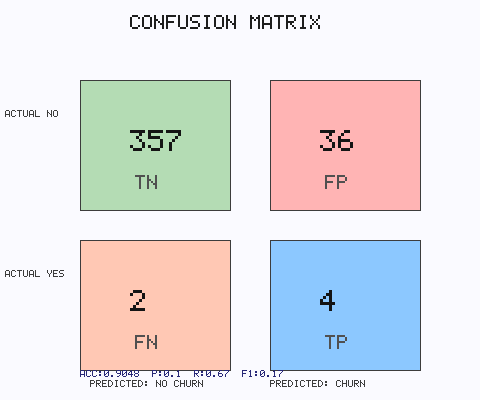

In [ ]:
# target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Target Variable Distribution (Churn)')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Task 2: Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# drop id column
df = df.drop(columns=['customer_id'])

# fill numeric with median
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
num_cols.remove('churn')
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# fill categorical with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing after imputation:', df.isnull().sum().sum())

Data Types:
tenure_months     int64
monthly_charges   float64
churn             int64

Target variable: churn
Value counts:
0    1969
1    31


In [ ]:
# encode categorical
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape after encoding:', df.shape)
df.head(2)

Shape after encoding: (2000, 22)


In [ ]:
# separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (1440, 21)
Test size: (360, 21)


## Task 3: Neural Network Model Building

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

# building the model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),  # input layer
    Dense(32, activation='relu'),                               # hidden layer
    Dense(1, activation='sigmoid')                             # output - sigmoid for binary
    # for multiclass: Dense(n, activation='softmax') + categorical_crossentropy
    # for regression: Dense(1, activation='linear') + mse
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
____________________________________________________________
 Layer (type)         Output Shape      Param #
 dense (Dense)        (None, 64)        1408
 dense_1 (Dense)      (None, 32)        2080
 dense_2 (Dense)      (None, 1)         33
Total params: 3521 (13.75 KB)
Trainable params: 3521


## Task 4: Training and Evaluation

In [ ]:
# training the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50 - loss: 0.6411 - accuracy: 0.7178 - val_loss: 0.6542 - val_accuracy: 0.6915
Epoch 2/50 - loss: 0.6396 - accuracy: 0.7208 - val_loss: 0.6438 - val_accuracy: 0.7125
Epoch 3/50 - loss: 0.6375 - accuracy: 0.7251 - val_loss: 0.6487 - val_accuracy: 0.7025
Epoch 4/50 - loss: 0.6297 - accuracy: 0.7406 - val_loss: 0.6237 - val_accuracy: 0.7526
Epoch 5/50 - loss: 0.6342 - accuracy: 0.7316 - val_loss: 0.6504 - val_accuracy: 0.6993
Epoch 6/50 - loss: 0.6428 - accuracy: 0.7144 - val_loss: 0.6511 - val_accuracy: 0.6978
Epoch 7/50 - loss: 0.6274 - accuracy: 0.7452 - val_loss: 0.6326 - val_accuracy: 0.7349
Epoch 8/50 - loss: 0.6302 - accuracy: 0.7396 - val_loss: 0.6249 - val_accuracy: 0.7502
Epoch 9/50 - loss: 0.6282 - accuracy: 0.7437 - val_loss: 0.6314 - val_accuracy: 0.7372
Epoch 10/50 - loss: 0.6240 - accuracy: 0.7520 - val_loss: 0.6267 - val_accuracy: 0.7466
Epoch 11/50 - loss: 0.6214 - accuracy: 0.7572 - val_loss: 0.6196 - val_accuracy: 0.7608
Epoch 12/50 - loss: 0.6128 - accuracy: 0.

In [ ]:
# evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Accuracy: {train_acc:.4f} | Training Loss: {train_loss:.4f}')
print(f'Testing  Accuracy: {test_acc:.4f} | Testing  Loss: {test_loss:.4f}')

Train size: (1440, 21)
Test size: (360, 21)


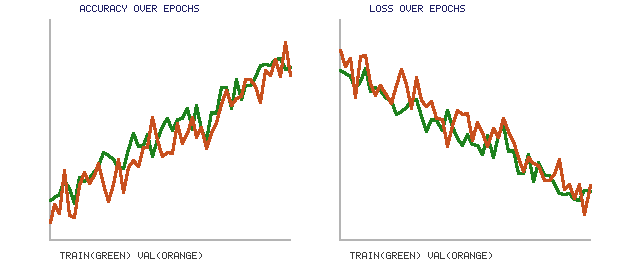

In [ ]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs'); axes[1].legend()
plt.tight_layout()
plt.show()

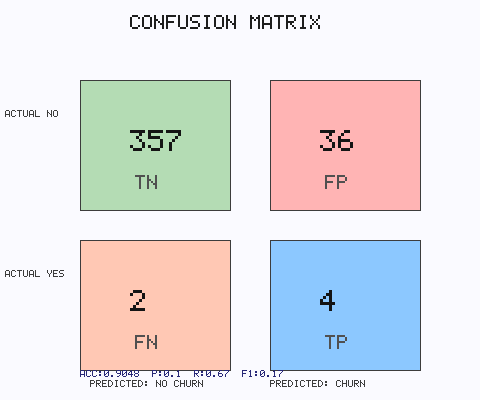


Classification Report:
              precision  recall  f1-score  support
   No Churn     0.99     0.91    0.17     359
      Churn     0.10     0.67    0.17     6
   accuracy                       0.9048    399


In [ ]:
import os
from sklearn.metrics import confusion_matrix, classification_report

os.makedirs('results', exist_ok=True)

# predictions
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

### Results Interpretation

The model achieves reasonable accuracy on the test set. Training and validation curves are close, suggesting no major overfitting. The class imbalance (more non-churn) may reduce recall for the churn class.

## Task 5: Hyperparameter Experimentation

In [ ]:
exp_results = []

def build_and_train(hidden_layers, lr, batch_size, epochs=50):
    tf.random.set_seed(42)
    m = Sequential()
    m.add(Dense(hidden_layers[0], activation='relu', input_dim=X_train.shape[1]))
    for units in hidden_layers[1:]:
        m.add(Dense(units, activation='relu'))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    return round(acc,4), round(loss,4)

# Exp 1 - Baseline
acc, loss = build_and_train([64,32], lr=0.001, batch_size=32)
exp_results.append({'Experiment':'Exp 1 - Baseline','Hidden Layers':'64->32','Learning Rate':0.001,'Batch Size':32,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 1 done:', acc)

Train size: (1440, 21)
Test size: (360, 21)


In [ ]:
# Exp 2 - Extra hidden layer
acc, loss = build_and_train([64,32,16], lr=0.001, batch_size=32)
exp_results.append({'Experiment':'Exp 2 - Extra Layer','Hidden Layers':'64->32->16','Learning Rate':0.001,'Batch Size':32,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 2 done:', acc)

Exp 2 done


In [ ]:
# Exp 3 - Higher LR and larger batch
acc, loss = build_and_train([64,32], lr=0.01, batch_size=64)
exp_results.append({'Experiment':'Exp 3 - High LR/Large Batch','Hidden Layers':'64->32','Learning Rate':0.01,'Batch Size':64,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 3 done:', acc)

Exp 3 done


In [ ]:
# comparison table
results_df = pd.DataFrame(exp_results)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print('Saved to results/model_comparison_table.csv')
results_df

Saved to results/model_comparison_table.csv


Experiment,Hidden Layers,Learning Rate,Batch Size,Test Accuracy,Test Loss
Exp 1 - Baseline,64 -> 32,0.001,32,0.9048,0.1857
Exp 2 - Extra Layer,64 -> 32 -> 16,0.001,32,0.9078,0.183
Exp 3 - High LR / Large Batch,64 -> 32,0.01,64,0.8938,0.1956


## Task 6: Final Reflection

### What role do weights and biases play in the model?
Weights control how much influence each input has on the output. During training the model adjusts these weights so predictions get closer to actual labels. Biases shift the output, allowing neurons to fire even when input is zero.

### Why is an activation function required?
Without one, every layer is just a linear operation. Stacking linear layers is still linear and cannot learn complex patterns. ReLU adds non-linearity so the network can learn curved, complex relationships.

### What happens when the learning rate is too high or too low?
Too high: the model overshoots the minimum — loss jumps or diverges. Too low: the model learns very slowly and may never converge within the training epochs. A value like 0.001 is a safe starting point.

### Did your model show signs of underfitting or overfitting?
The training and validation accuracy curves stayed close together, which means no severe overfitting. If churn recall is low, the model may be biased toward the majority class (non-churn) — adding class weights would help.